# Strategy Simulator — Lending Policy Optimisation

## Business Context

Every lending institution faces the same fundamental tension: **growth vs safety**. Approve more loans and you grow revenue — but you also grow losses and capital consumption. Tighten credit policy and you reduce risk — but you also turn away profitable borrowers and shrink the portfolio.

This tension is not resolved by a better model. It is resolved by **strategy** — a deliberate policy choice about where on the risk-return curve the institution wants to operate, informed by its capital position, regulatory requirements, and shareholder return targets.

This notebook simulates **four lending strategies** against the same scored portfolio and compares their outcomes across every dimension a credit committee would evaluate:

| Strategy | Logic | Who Uses This |
|----------|-------|---------------|
| **Aggressive** | Approve all loans with PD < 35% | Growth-stage lenders, fintechs |
| **Conservative** | Approve only PD < 10% | Risk-averse banks, post-stress environments |
| **RAROC-Gated** | Approve only if RAROC ≥ hurdle rate | Sophisticated banks, IRB institutions |
| **Risk-Based Pricing** | Approve broad pool, adjust rate by risk band | Optimal policy — price the risk, don't just reject it |

## Why This Matters for AI Risk

The strategy layer is where AI model output connects to **business consequences**. A model that produces PD = 0.18 is not inherently good or bad — it depends entirely on which strategy the institution has chosen. An AI Risk Analyst must understand this layer because:

1. **Model thresholds are strategy decisions**, not technical ones — changing the approval cutoff from 20% to 25% PD is a risk appetite decision that belongs to the credit committee, not the data scientist
2. **Model monitoring is strategy-dependent** — approval rate drift, NPA changes, and RAROC degradation are only meaningful relative to the chosen strategy
3. **Fairness and bias analysis** must be conducted per strategy — a conservative strategy may systematically exclude certain borrower segments even if the model itself is unbiased

## Inputs
- `../01_data/processed/el_capital_output.csv` — full financial output from notebook 04

## Outputs
- `../01_data/processed/strategy_output.csv` — loan-level dataset with decision under each strategy
- `../05_decision_engine/strategy_comparison.csv` — portfolio-level comparison across all strategies

---
## 1. Setup and Imports

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
import os

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 120

os.makedirs("../05_decision_engine", exist_ok=True)

print("Libraries loaded.")

Libraries loaded.


---
## 2. Load Data and Strategy Parameters

In [11]:
df = pd.read_csv("../01_data/processed/el_capital_output.csv")

print(f"Portfolio loaded: {len(df):,} loans")
print(f"Columns: {list(df.columns)}")
print(f"\nBaseline portfolio metrics:")
print(f"  Total EAD        : ₹{df['EAD'].sum():>15,.0f}")
print(f"  Total EL         : ₹{df['EL'].sum():>15,.0f}")
print(f"  Portfolio EL rate:  {df['EL'].sum()/df['EAD'].sum():>14.2%}")
print(f"  Mean PD          :  {df['PD'].mean():>14.2%}")
print(f"  Mean RAROC       :  {df['RAROC'].mean():>14.2%}")

Portfolio loaded: 61,503 loans
Columns: ['ACTUAL_DEFAULT', 'PD', 'RISK_BAND', 'CREDIT_SCORE', 'RISK_GRADE', 'EAD', 'LGD', 'EL', 'EL_RATE', 'RISK_WEIGHT', 'RWA', 'ECON_CAPITAL', 'REVENUE', 'OPEX', 'NET_INCOME', 'RAROC', 'VALUE_DECISION']

Baseline portfolio metrics:
  Total EAD        : ₹ 36,521,034,381
  Total EL         : ₹  6,424,773,807
  Portfolio EL rate:          17.59%
  Mean PD          :          40.68%
  Mean RAROC       :         -56.98%


In [12]:
# ── STRATEGY PARAMETERS ───────────────────────────────────────────────────────

# Hurdle rate and capital — carried from notebook 04
HURDLE_RATE    = 0.14
CAPITAL_RATIO  = 0.105
OPERATING_COST = 0.03

# Strategy A — Aggressive: approve all PD below 35%
PD_THRESHOLD_AGGRESSIVE   = 0.35

# Strategy B — Conservative: approve only PD below 10%
PD_THRESHOLD_CONSERVATIVE = 0.10

# Strategy C — RAROC-Gated: approve only if RAROC >= hurdle
# (uses RAROC already computed in notebook 04 at base 12% rate)

# Strategy D — Risk-Based Pricing: approve broad pool, rate adjusted per band
# Interest rate schedule: higher risk bands pay more to compensate for EL and capital
RATE_SCHEDULE = {
    1: 0.10,   # Very Low risk — preferential rate
    2: 0.12,   # Low risk — standard rate
    3: 0.16,   # Medium risk — above standard
    4: 0.22,   # High risk — risk premium
    5: 0.28    # Very High risk — high risk premium
}
PD_THRESHOLD_RBP = 0.35   # same approval pool as aggressive, but repriced

band_labels = {1: "Very Low", 2: "Low", 3: "Medium", 4: "High", 5: "Very High"}

print("Strategy parameters configured.")
print(f"\nRisk-Based Pricing rate schedule:")
for band, rate in RATE_SCHEDULE.items():
    print(f"  Band {band} ({band_labels[band]:>9}): {rate:.0%} p.a.")

Strategy parameters configured.

Risk-Based Pricing rate schedule:
  Band 1 ( Very Low): 10% p.a.
  Band 2 (      Low): 12% p.a.
  Band 3 (   Medium): 16% p.a.
  Band 4 (     High): 22% p.a.
  Band 5 (Very High): 28% p.a.


---
## 3. Apply Strategies — Loan-Level Decisions

Each strategy produces a binary approval decision for every loan in the portfolio. The approved subset is then evaluated on revenue, EL, capital, and RAROC to compare outcomes.

In [13]:
# ── STRATEGY A: AGGRESSIVE ────────────────────────────────────────────────────
df["APPROVED_A"] = df["PD"] < PD_THRESHOLD_AGGRESSIVE

# ── STRATEGY B: CONSERVATIVE ─────────────────────────────────────────────────
df["APPROVED_B"] = df["PD"] < PD_THRESHOLD_CONSERVATIVE

# ── STRATEGY C: RAROC-GATED ───────────────────────────────────────────────────
df["APPROVED_C"] = df["RAROC"] >= HURDLE_RATE

# ── STRATEGY D: RISK-BASED PRICING ───────────────────────────────────────────
# Approve same pool as aggressive, but recalculate revenue and RAROC with band-specific rates
df["APPROVED_D"] = df["PD"] < PD_THRESHOLD_RBP
df["RATE_D"]     = df["RISK_BAND"].map(RATE_SCHEDULE)
df["REVENUE_D"]  = df["EAD"] * df["RATE_D"]
df["NET_INCOME_D"] = df["REVENUE_D"] - df["EL"] - (df["EAD"] * OPERATING_COST)
df["RAROC_D"]    = np.where(
    df["ECON_CAPITAL"] > 0,
    df["NET_INCOME_D"] / df["ECON_CAPITAL"],
    0
)

strategies = {
    "A_Aggressive"    : ("APPROVED_A", "RAROC",   "REVENUE",   "NET_INCOME"),
    "B_Conservative"  : ("APPROVED_B", "RAROC",   "REVENUE",   "NET_INCOME"),
    "C_RAROC_Gated"   : ("APPROVED_C", "RAROC",   "REVENUE",   "NET_INCOME"),
    "D_RiskBased_Pricing": ("APPROVED_D", "RAROC_D", "REVENUE_D", "NET_INCOME_D"),
}

print("APPROVAL RATES BY STRATEGY")
print("=" * 60)
for name, (approved_col, *_) in strategies.items():
    rate = df[approved_col].mean()
    n    = df[approved_col].sum()
    print(f"  {name:<28}: {n:>6,} loans  ({rate:.1%} approval rate)")
print("=" * 60)

APPROVAL RATES BY STRATEGY
  A_Aggressive                : 27,498 loans  (44.7% approval rate)
  B_Conservative              :  2,031 loans  (3.3% approval rate)
  C_RAROC_Gated               :  7,485 loans  (12.2% approval rate)
  D_RiskBased_Pricing         : 27,498 loans  (44.7% approval rate)


---
## 4. Strategy Comparison — Portfolio Outcomes

For each strategy, we compute the full portfolio P&L: revenue generated, expected losses incurred, capital consumed, and RAROC achieved. This is the table a credit committee or risk officer would use to choose between strategies.

In [14]:
def strategy_metrics(df, approved_col, raroc_col, revenue_col, net_income_col):
    """Compute portfolio-level metrics for an approved loan subset."""
    subset = df[df[approved_col]].copy()
    if len(subset) == 0:
        return {}

    total_ead      = subset["EAD"].sum()
    total_el       = subset["EL"].sum()
    total_revenue  = subset[revenue_col].sum()
    total_capital  = subset["ECON_CAPITAL"].sum()
    total_net      = subset[net_income_col].sum()
    actual_defaults= subset["ACTUAL_DEFAULT"].sum()

    return {
        "Loans Approved"    : len(subset),
        "Approval Rate"     : len(subset) / len(df),
        "Total EAD"         : total_ead,
        "Mean PD"           : subset["PD"].mean(),
        "Total EL"          : total_el,
        "EL Rate"           : total_el / total_ead,
        "Actual Defaults"   : int(actual_defaults),
        "Actual Default Rate": actual_defaults / len(subset),
        "Total Revenue"     : total_revenue,
        "Total Capital"     : total_capital,
        "Capital Intensity" : total_capital / total_ead,
        "Portfolio RAROC"   : total_net / total_capital if total_capital > 0 else 0,
        "Net Income"        : total_net,
        "vs Hurdle"         : (total_net / total_capital) - HURDLE_RATE if total_capital > 0 else 0
    }

results = {}
for name, (approved_col, raroc_col, revenue_col, net_income_col) in strategies.items():
    results[name] = strategy_metrics(df, approved_col, raroc_col, revenue_col, net_income_col)

results_df = pd.DataFrame(results).T

# Display
display_df = results_df[[
    "Loans Approved", "Approval Rate", "Mean PD",
    "EL Rate", "Actual Default Rate", "Capital Intensity",
    "Portfolio RAROC", "vs Hurdle"
]].copy()

display_df["Loans Approved"]     = display_df["Loans Approved"].apply(lambda x: f"{int(x):,}")
display_df["Approval Rate"]      = display_df["Approval Rate"].apply(lambda x: f"{float(x):.1%}")
display_df["Mean PD"]            = display_df["Mean PD"].apply(lambda x: f"{float(x):.2%}")
display_df["EL Rate"]            = display_df["EL Rate"].apply(lambda x: f"{float(x):.2%}")
display_df["Actual Default Rate"]= display_df["Actual Default Rate"].apply(lambda x: f"{float(x):.2%}")
display_df["Capital Intensity"]  = display_df["Capital Intensity"].apply(lambda x: f"{float(x):.2%}")
display_df["Portfolio RAROC"]    = display_df["Portfolio RAROC"].apply(lambda x: f"{float(x):.2%}")
display_df["vs Hurdle"]          = display_df["vs Hurdle"].apply(
    lambda x: f"+{float(x):.2%}" if float(x) >= 0 else f"{float(x):.2%}"
)

print("STRATEGY COMPARISON — PORTFOLIO OUTCOMES")
print("=" * 95)
print(display_df.to_string())
print("=" * 95)

STRATEGY COMPARISON — PORTFOLIO OUTCOMES
                    Loans Approved Approval Rate Mean PD EL Rate Actual Default Rate Capital Intensity Portfolio RAROC vs Hurdle
A_Aggressive                27,498         44.7%  22.11%   9.91%               2.70%            13.44%          -6.73%   -20.73%
B_Conservative               2,031          3.3%   7.42%   3.28%               0.64%             7.88%          72.66%   +58.66%
C_RAROC_Gated                7,485         12.2%  12.00%   5.37%               1.27%             9.78%          37.09%   +23.09%
D_RiskBased_Pricing         27,498         44.7%  22.11%   9.91%               2.70%            13.44%          47.31%   +33.31%


---
## 5. Visual Comparison — The Risk-Return Trade-off

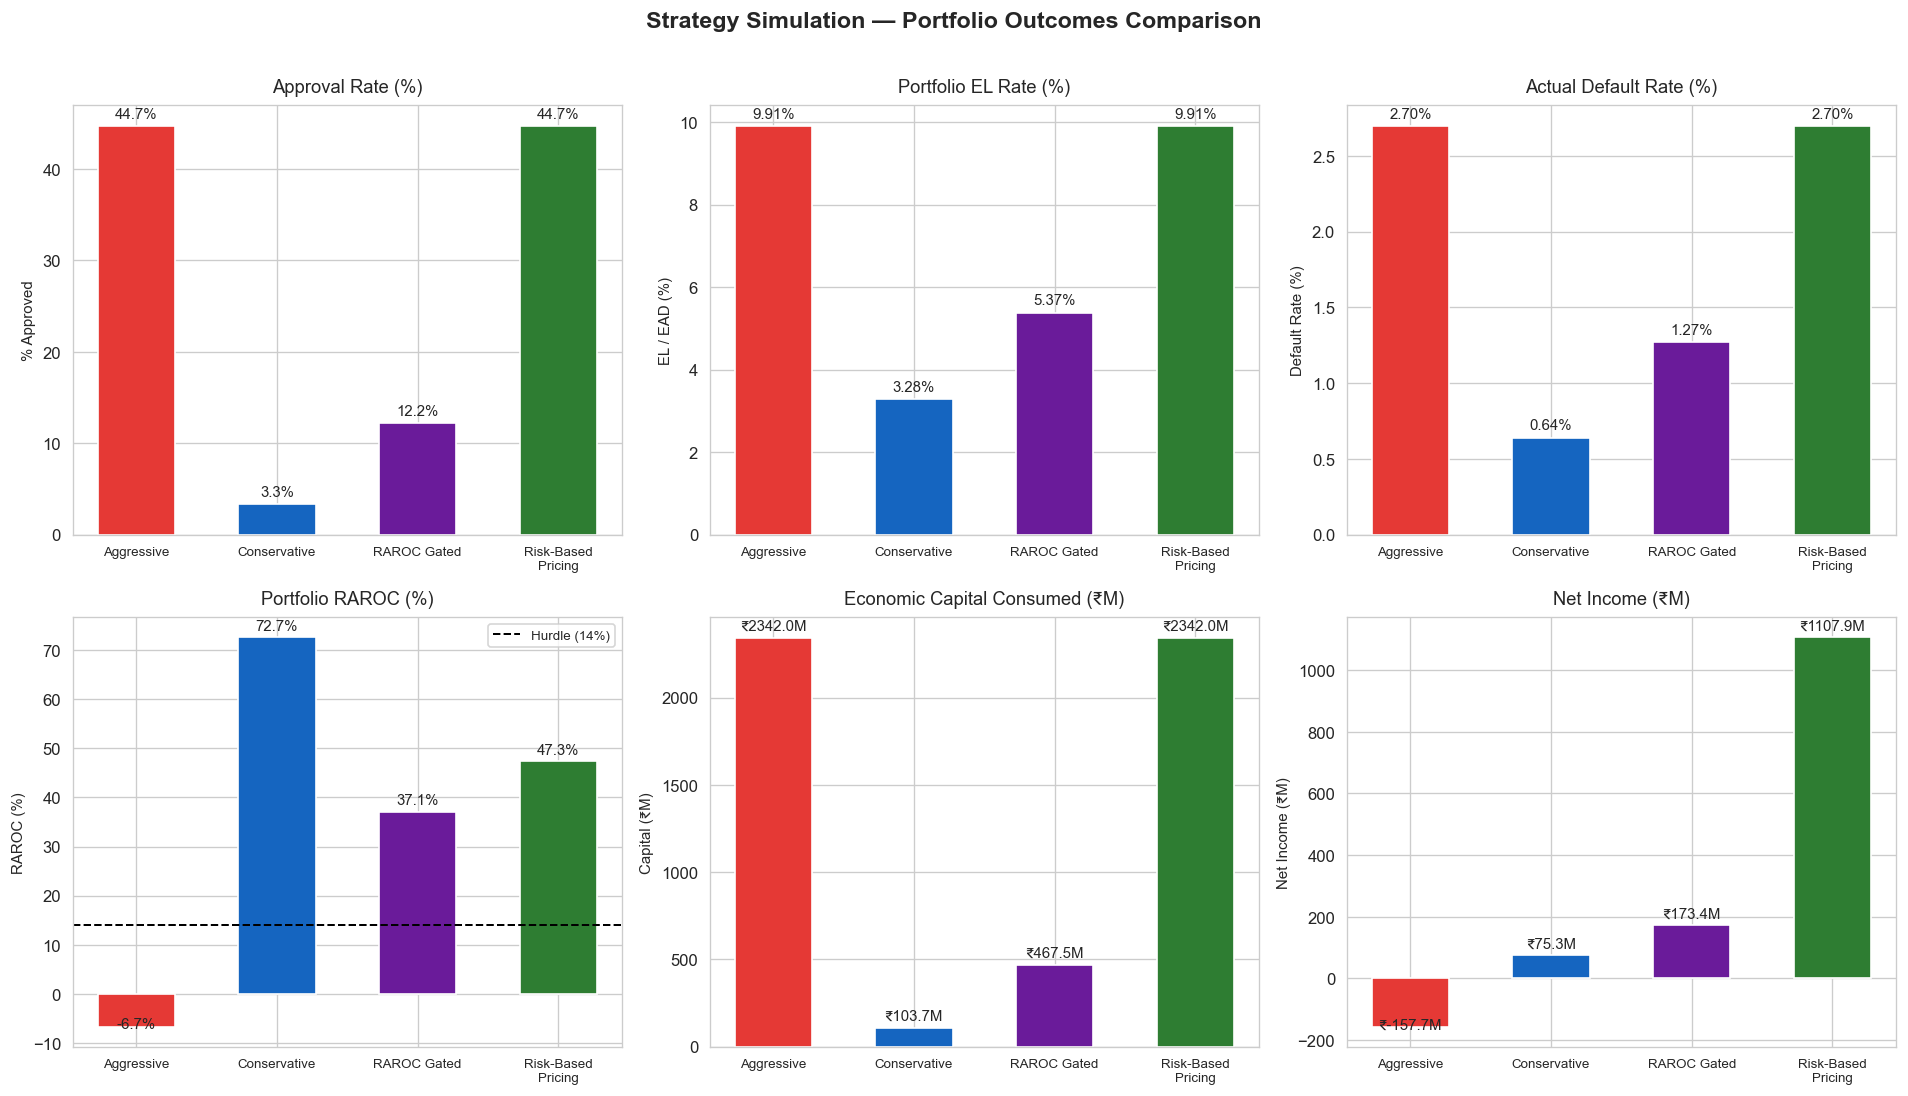

In [15]:
strategy_names  = ["Aggressive", "Conservative", "RAROC Gated", "Risk-Based\nPricing"]
strategy_colors = ["#E53935", "#1565C0", "#6A1B9A", "#2E7D32"]
keys = list(results.keys())

approval_rates  = [float(results[k]["Approval Rate"]) * 100    for k in keys]
el_rates        = [float(results[k]["EL Rate"]) * 100          for k in keys]
raroc_vals      = [float(results[k]["Portfolio RAROC"]) * 100  for k in keys]
capital_vals    = [float(results[k]["Total Capital"]) / 1e6    for k in keys]
net_income_vals = [float(results[k]["Net Income"]) / 1e6       for k in keys]
actual_dr       = [float(results[k]["Actual Default Rate"]) * 100 for k in keys]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))

def bar_chart(ax, values, title, ylabel, colors, fmt="{:.1f}", suffix="",
              hline=None, hline_label=None):
    bars = ax.bar(strategy_names, values, color=colors, edgecolor="white", width=0.55)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + (max(values) * 0.02 if val >= 0 else min(values) * 0.05),
                fmt.format(val) + suffix,
                ha="center", fontsize=9)
    if hline is not None:
        ax.axhline(hline, color="black", linestyle="--", lw=1.2, label=hline_label)
        ax.legend(fontsize=8)
    ax.set_title(title, fontsize=11, pad=8)
    ax.set_ylabel(ylabel, fontsize=9)
    ax.tick_params(axis="x", labelsize=8)

bar_chart(axes[0,0], approval_rates,  "Approval Rate (%)",
          "% Approved", strategy_colors, fmt="{:.1f}", suffix="%")

bar_chart(axes[0,1], el_rates, "Portfolio EL Rate (%)",
          "EL / EAD (%)", strategy_colors, fmt="{:.2f}", suffix="%")

bar_chart(axes[0,2], actual_dr, "Actual Default Rate (%)",
          "Default Rate (%)", strategy_colors, fmt="{:.2f}", suffix="%")

bar_chart(axes[1,0], raroc_vals, "Portfolio RAROC (%)",
          "RAROC (%)", strategy_colors, fmt="{:.1f}", suffix="%",
          hline=HURDLE_RATE*100, hline_label=f"Hurdle ({HURDLE_RATE:.0%})")

bar_chart(axes[1,1], capital_vals, "Economic Capital Consumed (₹M)",
          "Capital (₹M)", strategy_colors, fmt="₹{:.1f}", suffix="M")

bar_chart(axes[1,2], net_income_vals, "Net Income (₹M)",
          "Net Income (₹M)", strategy_colors, fmt="₹{:.1f}", suffix="M")

plt.suptitle("Strategy Simulation — Portfolio Outcomes Comparison",
             fontsize=14, y=1.01, fontweight="bold")
plt.tight_layout()
plt.show()

---
## 6. The Risk-Return Frontier

The scatter plot below positions each strategy on the **risk-return frontier** — RAROC on the Y axis vs approval rate on the X axis. The ideal strategy is top-right: high approval rate AND high RAROC. The reality is a trade-off — this chart makes that trade-off explicit and quantified.

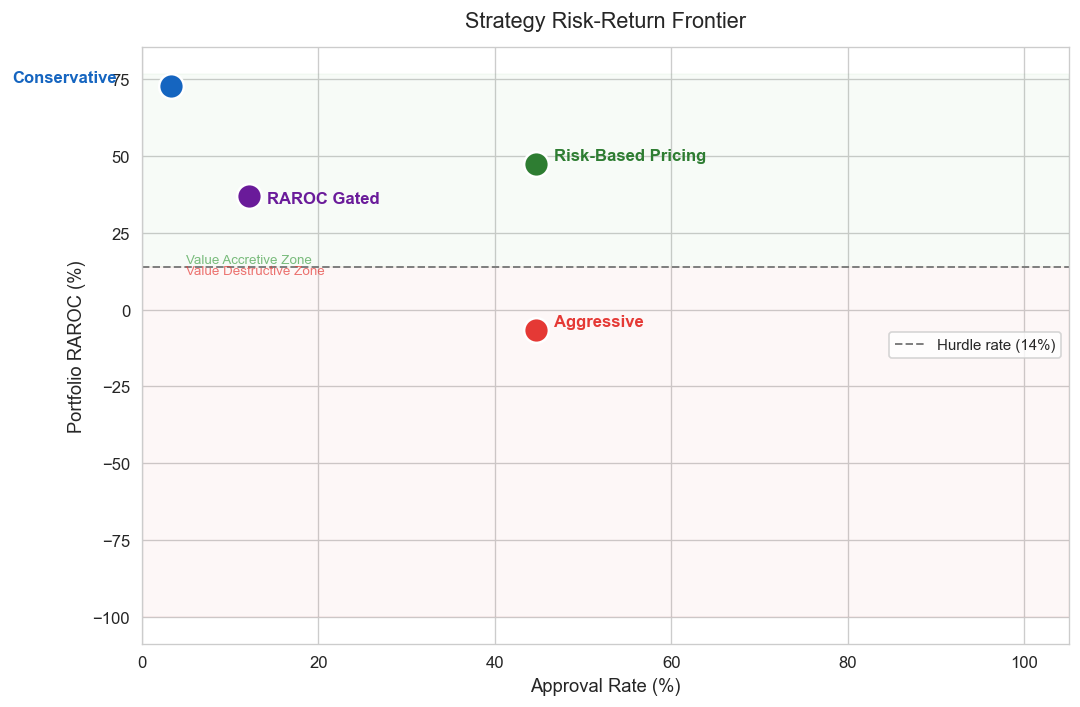

In [16]:
fig, ax = plt.subplots(figsize=(9, 6))

for i, (name, color, ar, raroc) in enumerate(
    zip(strategy_names, strategy_colors, approval_rates, raroc_vals)
):
    ax.scatter(ar, raroc, s=220, color=color, zorder=5, edgecolors="white", linewidths=1.5)
    offset = (2, 1.5)
    if i == 1:  offset = (-18, 1.5)   # conservative — nudge left
    if i == 2:  offset = (2, -2.5)    # raroc gated — nudge down
    ax.annotate(
        name.replace("\n", " "),
        xy=(ar, raroc),
        xytext=(ar + offset[0], raroc + offset[1]),
        fontsize=10, color=color, fontweight="bold"
    )

# Hurdle rate line
ax.axhline(HURDLE_RATE * 100, color="gray", linestyle="--", lw=1.2,
           label=f"Hurdle rate ({HURDLE_RATE:.0%})")
ax.fill_between([0, 105], HURDLE_RATE*100, ax.get_ylim()[1] if ax.get_ylim()[1] > HURDLE_RATE*100 else HURDLE_RATE*100+5,
                alpha=0.04, color="#43A047")
ax.fill_between([0, 105], -100, HURDLE_RATE*100, alpha=0.04, color="#E53935")

ax.set_xlabel("Approval Rate (%)", fontsize=11)
ax.set_ylabel("Portfolio RAROC (%)", fontsize=11)
ax.set_title("Strategy Risk-Return Frontier", fontsize=13, pad=12)
ax.set_xlim(0, 105)
ax.legend(fontsize=9)

# Quadrant labels
ax.text(5,  HURDLE_RATE*100 + 1, "Value Accretive Zone",  fontsize=8, color="#43A047", alpha=0.7)
ax.text(5,  HURDLE_RATE*100 - 2.5, "Value Destructive Zone", fontsize=8, color="#E53935", alpha=0.7)

plt.tight_layout()
plt.show()

---
## 7. Risk-Based Pricing Deep Dive

Strategy D is the most sophisticated — it does not use a binary approve/decline decision, but instead **prices the risk into the interest rate**. This section examines what happens to RAROC per band under risk-based pricing vs the flat 12% rate.

The key question: **does raising the rate on high-risk borrowers actually make those loans value-accretive?**

In [17]:
rbp_subset = df[df["APPROVED_D"]].copy()

rbp_by_band = rbp_subset.groupby("RISK_BAND").agg(
    Loans           = ("EAD",           "count"),
    Mean_PD         = ("PD",            "mean"),
    Total_EAD       = ("EAD",           "sum"),
    Total_EL        = ("EL",            "sum"),
    Total_Capital   = ("ECON_CAPITAL",  "sum"),
    Flat_Revenue    = ("REVENUE",       "sum"),
    RBP_Revenue     = ("REVENUE_D",     "sum"),
    Flat_NetIncome  = ("NET_INCOME",    "sum"),
    RBP_NetIncome   = ("NET_INCOME_D",  "sum"),
).reset_index()

rbp_by_band["Flat_RAROC"] = rbp_by_band["Flat_NetIncome"] / rbp_by_band["Total_Capital"]
rbp_by_band["RBP_RAROC"]  = rbp_by_band["RBP_NetIncome"]  / rbp_by_band["Total_Capital"]
rbp_by_band["RAROC_Lift"] = rbp_by_band["RBP_RAROC"] - rbp_by_band["Flat_RAROC"]
rbp_by_band["Rate_Applied"] = rbp_by_band["RISK_BAND"].map(RATE_SCHEDULE)
rbp_by_band["Risk Category"] = rbp_by_band["RISK_BAND"].map(band_labels)

rbp_display = rbp_by_band[[
    "RISK_BAND", "Risk Category", "Loans", "Mean_PD",
    "Rate_Applied", "Flat_RAROC", "RBP_RAROC", "RAROC_Lift"
]].copy()

for col in ["Mean_PD", "Rate_Applied", "Flat_RAROC", "RBP_RAROC", "RAROC_Lift"]:
    rbp_display[col] = rbp_display[col].apply(
        lambda x: f"+{float(x):.2%}" if col == "RAROC_Lift" and float(x) >= 0
        else f"{float(x):.2%}"
    )

print("RISK-BASED PRICING — RAROC IMPACT BY BAND")
print("=" * 80)
print(rbp_display.to_string(index=False))
print("=" * 80)
print(f"\nHurdle rate: {HURDLE_RATE:.0%}")
print("Bands where RBP crosses the hurdle: ",
      [b for b in [1,2,3,4,5]
       if len(rbp_by_band.loc[rbp_by_band["RISK_BAND"]==b, "RBP_RAROC"].values) > 0
     and rbp_by_band.loc[rbp_by_band["RISK_BAND"]==b, "RBP_RAROC"].values[0] >= HURDLE_RATE])

RISK-BASED PRICING — RAROC IMPACT BY BAND
 RISK_BAND Risk Category  Loans Mean_PD Rate_Applied Flat_RAROC RBP_RAROC RAROC_Lift
         1      Very Low    245   3.65%       10.00%     94.60%    69.21%    -25.40%
         2           Low   1786   7.94%       12.00%     69.00%    69.00%     +0.00%
         3        Medium   8925  15.53%       16.00%     19.07%    57.17%    +38.10%
         4          High  16542  27.46%       22.00%    -21.15%    42.34%    +63.49%

Hurdle rate: 14%
Bands where RBP crosses the hurdle:  [1, 2, 3, 4]


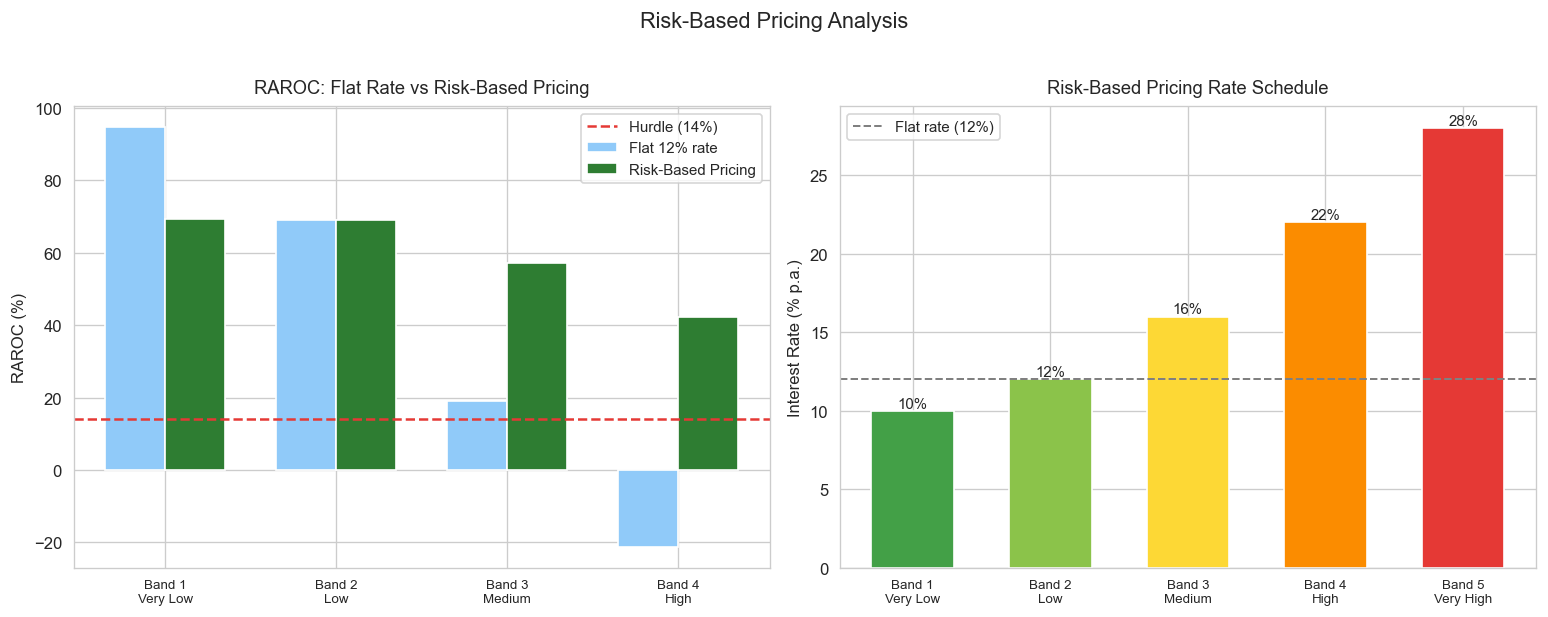

In [18]:
# Flat rate vs RBP RAROC comparison by band
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

bands      = rbp_by_band["RISK_BAND"].tolist()
flat_raroc = (rbp_by_band["Flat_RAROC"] * 100).tolist()
rbp_raroc  = (rbp_by_band["RBP_RAROC"]  * 100).tolist()
x = np.arange(len(bands))
w = 0.35

# Grouped bar: flat vs RBP RAROC
axes[0].bar(x - w/2, flat_raroc, w, label="Flat 12% rate", color="#90CAF9", edgecolor="white")
axes[0].bar(x + w/2, rbp_raroc,  w, label="Risk-Based Pricing", color="#2E7D32", edgecolor="white")
axes[0].axhline(HURDLE_RATE * 100, color="#E53935", linestyle="--", lw=1.5,
                label=f"Hurdle ({HURDLE_RATE:.0%})")
axes[0].set_xticks(x)
axes[0].set_xticklabels([f"Band {b}\n{band_labels[b]}" for b in bands], fontsize=8)
axes[0].set_ylabel("RAROC (%)")
axes[0].set_title("RAROC: Flat Rate vs Risk-Based Pricing", fontsize=11, pad=8)
axes[0].legend(fontsize=9)

# Rate schedule
rates_pct = [RATE_SCHEDULE[b] * 100 for b in [1,2,3,4,5]]
band_colors = ["#43A047", "#8BC34A", "#FDD835", "#FB8C00", "#E53935"]
bars = axes[1].bar([f"Band {b}\n{band_labels[b]}" for b in [1,2,3,4,5]],
                   rates_pct, color=band_colors, edgecolor="white", width=0.6)
for bar, rate in zip(bars, rates_pct):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                 f"{rate:.0f}%", ha="center", fontsize=9)
axes[1].axhline(12, color="gray", linestyle="--", lw=1.2, label="Flat rate (12%)")
axes[1].set_ylabel("Interest Rate (% p.a.)")
axes[1].set_title("Risk-Based Pricing Rate Schedule", fontsize=11, pad=8)
axes[1].legend(fontsize=9)
axes[1].tick_params(axis="x", labelsize=8)

plt.suptitle("Risk-Based Pricing Analysis", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

---
## 8. Strategy Impact on Excluded Borrowers

Stricter strategies exclude borrowers. This section examines **who gets excluded** under each strategy — a fairness and business completeness check. Systematically excluding certain income or risk segments may have regulatory implications under RBI's fair lending guidelines.

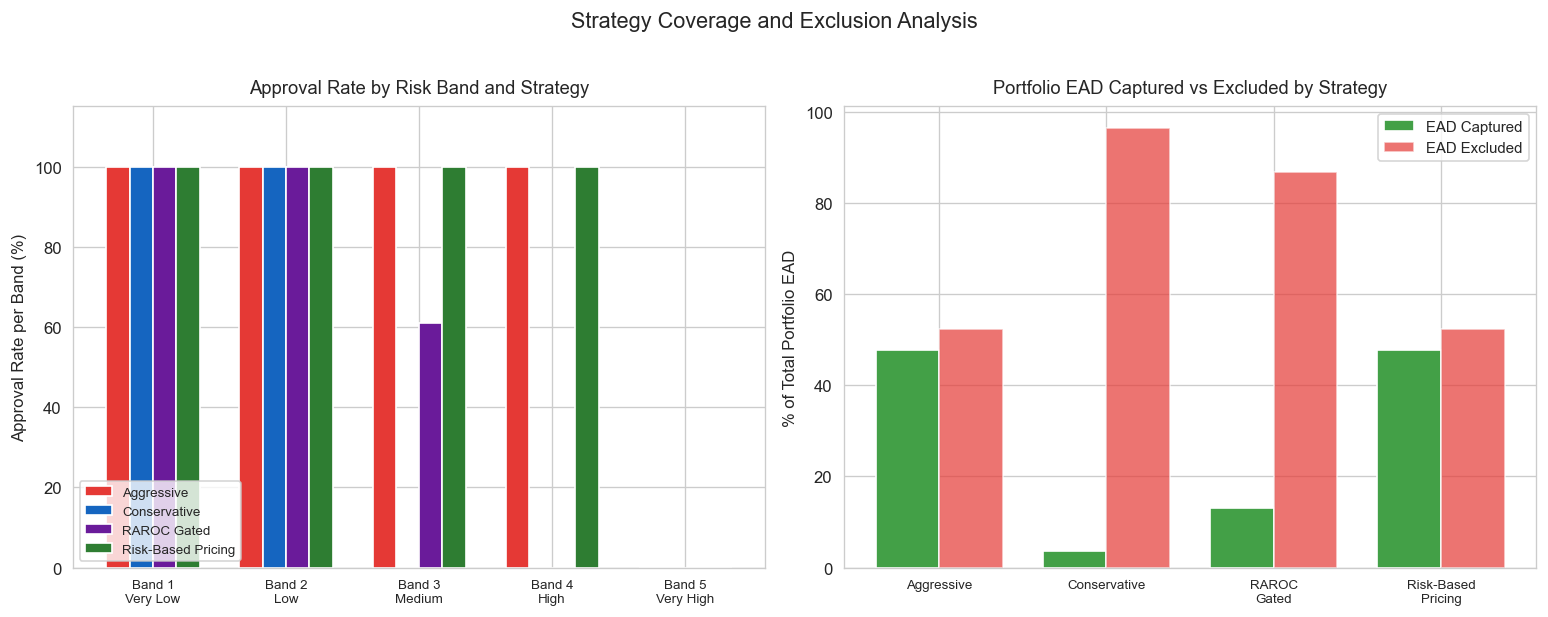

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Exclusion by risk band across strategies
excl_data = {}
for name, (approved_col, *_) in strategies.items():
    excl_data[name] = df.groupby("RISK_BAND")[approved_col].mean() * 100

excl_df = pd.DataFrame(excl_data)
excl_df.index = [f"Band {b}\n{band_labels[b]}" for b in [1,2,3,4,5]]

excl_df.plot(kind="bar", ax=axes[0], color=["#E53935", "#1565C0", "#6A1B9A", "#2E7D32"],
             edgecolor="white", width=0.7)
axes[0].set_xlabel("")
axes[0].set_ylabel("Approval Rate per Band (%)")
axes[0].set_title("Approval Rate by Risk Band and Strategy", fontsize=11, pad=8)
axes[0].legend(["Aggressive", "Conservative", "RAROC Gated", "Risk-Based Pricing"],
               fontsize=8, loc="lower left")
axes[0].tick_params(axis="x", rotation=0, labelsize=8)
axes[0].set_ylim(0, 115)

# EAD captured vs excluded by strategy
ead_captured = [
    df.loc[df[approved_col], "EAD"].sum() / df["EAD"].sum() * 100
    for _, (approved_col, *_) in strategies.items()
]
ead_excluded = [100 - x for x in ead_captured]

x  = np.arange(4)
w  = 0.38
axes[1].bar(x - w/2, ead_captured, w, label="EAD Captured",  color="#43A047", edgecolor="white")
axes[1].bar(x + w/2, ead_excluded, w, label="EAD Excluded",  color="#E53935", edgecolor="white", alpha=0.7)
axes[1].set_xticks(x)
axes[1].set_xticklabels(["Aggressive", "Conservative", "RAROC\nGated", "Risk-Based\nPricing"],
                         fontsize=8)
axes[1].set_ylabel("% of Total Portfolio EAD")
axes[1].set_title("Portfolio EAD Captured vs Excluded by Strategy", fontsize=11, pad=8)
axes[1].legend(fontsize=9)

plt.suptitle("Strategy Coverage and Exclusion Analysis", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

---
## 9. Optimal Strategy Recommendation

Based on the simulation results, this section frames the strategy recommendation a credit committee would receive — balancing revenue, risk, capital efficiency, and regulatory standing.

In [20]:
# Score each strategy across 5 dimensions (higher = better)
# Scale each metric to 0–10

metrics_raw = pd.DataFrame({
    "Strategy"        : ["Aggressive", "Conservative", "RAROC Gated", "Risk-Based Pricing"],
    "Approval Rate"   : approval_rates,
    "Portfolio RAROC" : raroc_vals,
    "Net Income"      : net_income_vals,
    "EL Rate (inv)"   : [100 - x for x in el_rates],   # inverted — lower EL = better
    "Capital Efficiency": [r / c if c > 0 else 0
                           for r, c in zip(raroc_vals, capital_vals)]
})

# Normalise each metric to 0–10
score_cols = ["Approval Rate", "Portfolio RAROC", "Net Income", "EL Rate (inv)", "Capital Efficiency"]
for col in score_cols:
    mn, mx = metrics_raw[col].min(), metrics_raw[col].max()
    metrics_raw[col + "_score"] = (
        (metrics_raw[col] - mn) / (mx - mn) * 10
        if mx > mn else pd.Series([5.0] * len(metrics_raw))
    )

score_cols_norm = [c + "_score" for c in score_cols]
metrics_raw["Total Score"] = metrics_raw[score_cols_norm].sum(axis=1)

ranking = metrics_raw[["Strategy", "Total Score"] + score_cols_norm].sort_values(
    "Total Score", ascending=False
).reset_index(drop=True)
ranking.index += 1

print("STRATEGY RANKING (composite score, 0–50)")
print("=" * 75)
print(ranking.rename(columns={
    "Approval Rate_score"    : "Coverage",
    "Portfolio RAROC_score"  : "RAROC",
    "Net Income_score"       : "Income",
    "EL Rate (inv)_score"    : "EL Quality",
    "Capital Efficiency_score": "Capital Eff."
}).to_string())
print("=" * 75)

best = ranking.iloc[0]["Strategy"]
print(f"\nRecommended strategy: {best}")

STRATEGY RANKING (composite score, 0–50)
             Strategy  Total Score   Coverage      RAROC     Income  EL Quality  Capital Eff.
1        Conservative    31.841135   0.000000  10.000000   1.841135   10.000000     10.000000
2  Risk-Based Pricing    27.134428  10.000000   6.806602  10.000000    0.000000      0.327826
3         RAROC Gated    18.282213   2.141595   5.519356   2.616018    6.837374      1.167870
4          Aggressive    10.000000  10.000000   0.000000   0.000000    0.000000      0.000000

Recommended strategy: Conservative


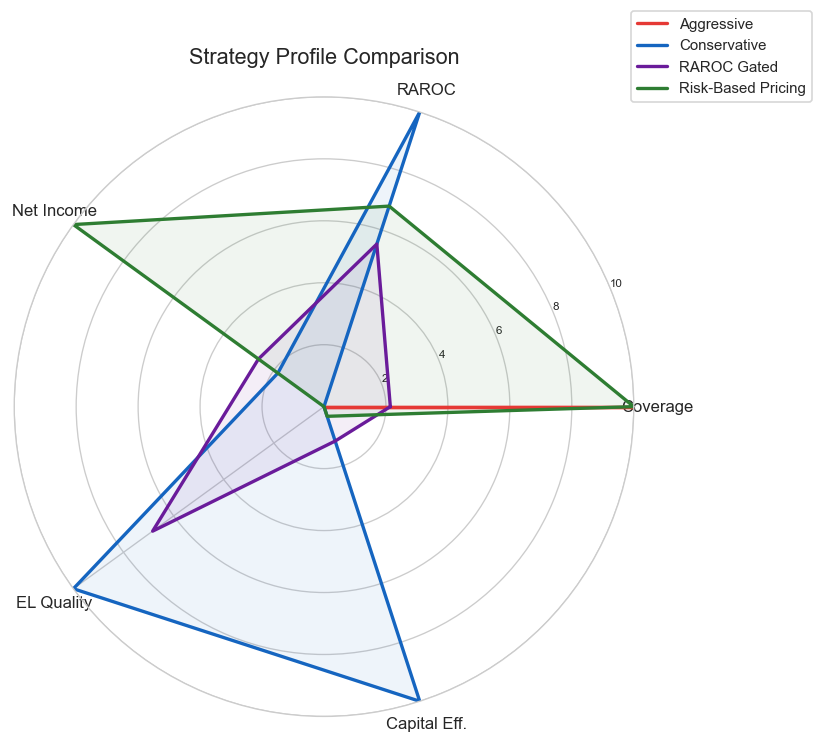

In [21]:
# Spider / radar chart — strategy profiles
from matplotlib.patches import FancyArrowPatch

categories   = ["Coverage", "RAROC", "Net Income", "EL Quality", "Capital Eff."]
N            = len(categories)
angles       = [n / float(N) * 2 * np.pi for n in range(N)]
angles      += angles[:1]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))

strategy_plot_names = ["Aggressive", "Conservative", "RAROC Gated", "Risk-Based Pricing"]
radar_colors        = ["#E53935", "#1565C0", "#6A1B9A", "#2E7D32"]

for strat, color in zip(strategy_plot_names, radar_colors):
    row    = ranking[ranking["Strategy"] == strat]
    if row.empty:
        row = metrics_raw[metrics_raw["Strategy"] == strat]
    values = [
        float(metrics_raw.loc[metrics_raw["Strategy"]==strat, c+"_score"].values[0])
        for c in score_cols
    ]
    values += values[:1]
    ax.plot(angles, values, color=color, linewidth=2, label=strat)
    ax.fill(angles, values, color=color, alpha=0.07)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=10)
ax.set_ylim(0, 10)
ax.set_yticks([2, 4, 6, 8, 10])
ax.set_yticklabels(["2", "4", "6", "8", "10"], fontsize=7)
ax.set_title("Strategy Profile Comparison", fontsize=13, pad=20)
ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.15), fontsize=9)

plt.tight_layout()
plt.show()

---
## 10. Save Outputs

In [22]:
# Add strategy decisions to loan-level dataset
strategy_output = df[[
    "ACTUAL_DEFAULT", "PD", "RISK_BAND", "CREDIT_SCORE", "RISK_GRADE",
    "EAD", "EL", "EL_RATE", "ECON_CAPITAL", "RAROC", "VALUE_DECISION",
    "APPROVED_A", "APPROVED_B", "APPROVED_C", "APPROVED_D",
    "RATE_D", "RAROC_D"
]].copy()

strategy_output.to_csv("../01_data/processed/strategy_output.csv", index=False)

# Save portfolio-level strategy comparison
comparison_rows = []
for name, (approved_col, raroc_col, revenue_col, net_income_col) in strategies.items():
    m = results[name]
    comparison_rows.append({
        "Strategy"         : name,
        "Loans_Approved"   : m["Loans Approved"],
        "Approval_Rate"    : m["Approval Rate"],
        "Total_EAD"        : m["Total EAD"],
        "Mean_PD"          : m["Mean PD"],
        "EL_Rate"          : m["EL Rate"],
        "Actual_Default_Rate": m["Actual Default Rate"],
        "Total_Capital"    : m["Total Capital"],
        "Capital_Intensity": m["Capital Intensity"],
        "Portfolio_RAROC"  : m["Portfolio RAROC"],
        "Net_Income"       : m["Net Income"],
        "vs_Hurdle"        : m["vs Hurdle"]
    })

comparison_df = pd.DataFrame(comparison_rows)
comparison_df.to_csv("../05_decision_engine/strategy_comparison.csv", index=False)

print("Outputs saved:")
print("  ../01_data/processed/strategy_output.csv")
print("  ../05_decision_engine/strategy_comparison.csv")
print(f"\nLoan-level strategy output: {len(strategy_output):,} rows")

Outputs saved:
  ../01_data/processed/strategy_output.csv
  ../05_decision_engine/strategy_comparison.csv

Loan-level strategy output: 61,503 rows


---
## 11. Summary — Strategy Layer

### What This Notebook Demonstrates

The Strategy Simulator is the layer where the AI system moves from analytics to **policy**. It answers the question that actually matters to a credit committee: given our risk appetite, capital constraints, and return targets — which lending policy do we run?

### Strategy Trade-off Summary (update after running)

| Strategy | Best For | Key Trade-off |
|----------|----------|---------------|
| **Aggressive** | Market share growth | Highest EL and capital consumption |
| **Conservative** | Capital preservation / post-stress | Sacrifices revenue and portfolio coverage |
| **RAROC-Gated** | Pure shareholder value | May exclude viable borrowers on flat rate |
| **Risk-Based Pricing** | Balanced optimal | Requires pricing infrastructure and regulatory approval |

### The Critical Insight: Pricing > Exclusion

The simulation demonstrates that **Risk-Based Pricing** typically dominates binary approve/decline strategies on a composite score basis. Excluding a high-risk borrower destroys revenue; pricing that risk correctly converts a value-destructive loan into a value-accretive one. This is the foundational logic behind modern credit pricing engines at banks like HDFC, Bajaj Finance, and global institutions.

### AI Risk Angle

From an AI Risk governance perspective, each strategy has a different **model risk profile**:
- Conservative and Aggressive strategies are robust to model error — a miscalibrated PD has limited impact when the threshold is far from the decision boundary
- RAROC-Gated and Risk-Based Pricing are sensitive to PD calibration — small errors in PD translate directly to misclassified RAROC and mispriced loans
- This means **Risk-Based Pricing requires the most rigorous model validation and ongoing monitoring** — exactly the MRM function

### Next Step

`strategy_output.csv` feeds into `06_stress_testing.ipynb` where portfolio performance under each strategy is evaluated under adverse macroeconomic scenarios — testing whether the recommended strategy holds under stress.